# Fine-tuning Qwen3-8B with RL (GRPO)

An end-to-end example of reinforcement learning on a local LLM: load the Qwen3-8B checkpoint from
`/vol/bitbucket/ma5923/llms/Qwen3-8B`, then improve it on a small task with **GRPO** (Group
Relative Policy Optimisation) and a **verifiable reward**.

**The task.** Three-digit multiplication (`398 * 274`), answered in a strict format:

```
<answer>109052</answer>
```

The reward is *programmatically checkable* — no reward model, no human labels. This is the RLVR
setup (RL with verifiable rewards) used for maths and code reasoning, shrunk to something that
trains in minutes.

**Why GRPO rather than PPO.** PPO needs a separate value network — a second model of comparable
size held in memory. GRPO drops it: for each prompt it samples a *group* of $G$ completions and
uses the group's own reward statistics as the baseline,

$$A_i = \frac{r_i - \mathrm{mean}(r_{1..G})}{\mathrm{std}(r_{1..G})}$$

which then feeds a clipped policy-gradient loss. The consequence that governs everything below:

> **If every completion in a group gets the same reward, the advantage is exactly zero and the
> prompt contributes no gradient.**

So the task must be one the model is *genuinely uncertain about* — not too easy, not too hard, and
crucially not deterministic. Section 2 measures this rather than assuming it, because the first
version of this notebook trained for 30 steps against a saturated reward and learned nothing at all.

**What is trained.** A LoRA adapter (~44M params) over the frozen bf16 base model. Full-parameter
RL on 8B would need roughly 96 GB of optimiser state alone.

## 0. Environment

Needs `transformers`, `trl`, `peft`, `datasets`, `accelerate`, which are **not** in the project
`.venv` — installing them there forces `huggingface_hub` 0.36 → 1.x and would break
`huggingface-sb3`, which this repo's SB3 tutorials depend on. They live in a separate env:

```bash
/vol/bitbucket/ma5923/llms/.venv-llm/bin/python -m ipykernel install \
    --prefix /vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/.venv --name llm-rl
```

Select the **llm-rl (Qwen RL)** kernel before running. (`--user` fails on this machine: the NFS home
is over its file-count quota, which is also why IPython prints a `history.sqlite` warning on start —
harmless.)

In [1]:
import os

# Pin to one GPU. Must happen before torch is imported.
# The 8B model in bf16 is ~16 GB and fits comfortably on a single 46 GB L40; sharding it across
# both GPUs would only add cross-device traffic.
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
os.environ.setdefault("HF_HOME", "/vol/bitbucket/ma5923/llms/.hf")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import re
import random
import statistics
from pathlib import Path

import torch
import transformers
import trl
import peft
from datasets import Dataset

MODEL_PATH = Path("/vol/bitbucket/ma5923/llms/Qwen3-8B")
OUTPUT_DIR = Path("/vol/bitbucket/ma5923/llms/runs/qwen3-8b-grpo-multiply")

assert MODEL_PATH.exists(), f"model not found at {MODEL_PATH}"
assert torch.cuda.is_available(), "no GPU visible"

print(f"transformers {transformers.__version__} | trl {trl.__version__} | peft {peft.__version__}")
print(f"torch        {torch.__version__}")
print(f"gpu          {torch.cuda.get_device_name(0)} "
      f"({torch.cuda.get_device_properties(0).total_memory / 1e9:.0f} GB)")

transformers 5.17.0 | trl 1.12.0 | peft 0.20.0
torch        2.10.0+cu128
gpu          NVIDIA L40 (48 GB)


## 1. Load the model

Straight from the local directory — no network, no repo id. `dtype=torch.bfloat16` is what the
checkpoint was released in, so nothing is lost against fp32 and memory halves.

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    dtype=torch.bfloat16,
    device_map={"": 0},          # whole model on GPU 0
)

print(f"{model.num_parameters() / 1e9:.2f}B params, "
      f"{torch.cuda.memory_allocated() / 1e9:.1f} GB allocated")

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

8.19B params, 16.4 GB allocated


### The Qwen3 thinking-mode gotcha

Qwen3 is a *hybrid reasoning* model: by default its chat template opens a `<think>` block and the
model spends hundreds of tokens reasoning before answering. Useful in production, ruinous here —
every completion would blow the token budget and the reward would mostly measure whether the answer
got truncated.

`enable_thinking=False` makes the template emit an empty `<think></think>` pair, putting the model
straight into answering mode.

In [3]:
SYSTEM_PROMPT = (
    "You are a calculator. Compute the product and reply with only the final answer "
    "inside <answer></answer> tags. Do not explain."
)


def render_prompt(a: int, b: int) -> str:
    """Render one problem into a plain prompt string, with thinking mode disabled."""
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": f"{a} * {b}"},
    ]
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )


print("=== enable_thinking=False (what we use) ===")
print(render_prompt(398, 274))
print("=== enable_thinking=True (the default) ===")
print(tokenizer.apply_chat_template(
    [{"role": "user", "content": "398 * 274"}],
    tokenize=False, add_generation_prompt=True, enable_thinking=True,
))

=== enable_thinking=False (what we use) ===
<|im_start|>system
You are a calculator. Compute the product and reply with only the final answer inside <answer></answer> tags. Do not explain.<|im_end|>
<|im_start|>user
398 * 274<|im_end|>
<|im_start|>assistant
<think>

</think>


=== enable_thinking=True (the default) ===
<|im_start|>user
398 * 274<|im_end|>
<|im_start|>assistant



Rendering prompts to strings here, rather than handing TRL a conversational dataset, keeps
`enable_thinking` under our control and makes the dataset a plain `prompt` → `completion` mapping.
It also means the reward functions receive completions as plain strings.

The generation helper below is deliberately defensive about two things that are easy to get wrong:

- **`model.eval()`** — `Trainer.train()` leaves the model in *training* mode. Generating in that
  state produces fluent-looking garbage (`'<el)).text)\ns)), is)infracmaths'`), which is very easy to
  misread as "RL destroyed my model" when nothing is wrong with the weights at all.
- **left padding** — with right padding the model would continue from pad tokens.

In [4]:
def generate(model, prompts, max_new_tokens=48, temperature=0.6, top_p=0.95):
    """Sample completions. Safe to call before or after training."""
    model.eval()                          # Trainer.train() leaves the model in train mode
    tokenizer.padding_side = "left"       # required for correct batched generation

    batch = tokenizer(prompts, return_tensors="pt", padding=True).to(model.device)
    with torch.no_grad():
        output = model.generate(
            **batch,
            max_new_tokens=max_new_tokens,
            do_sample=temperature > 0,
            temperature=temperature,
            top_p=top_p,
            use_cache=True,
            pad_token_id=tokenizer.pad_token_id,
        )
    # generate() returns prompt + completion; strip the prompt.
    return tokenizer.batch_decode(output[:, batch["input_ids"].shape[1]:], skip_special_tokens=True)


for text in generate(model, [render_prompt(398, 274), render_prompt(157, 193)]):
    print(repr(text))

'<answer>108852</answer>'
'<answer>30201</answer>'


## 2. Choosing a task the model can actually learn from

This is the step worth taking seriously. GRPO learns from *disagreement inside a group of samples
for one prompt*, so a task is only trainable if it sits in a narrow band. Two ways to fall out of it:

**Too easy / too hard — no spread across problems.** Measured on this model, `n=32`, greedy-ish
decoding:

| task | format | accuracy |
|---|---|---|
| 2-digit × 2-digit | 100% | **100%** — saturated, no signal |
| 3-digit × 2-digit | 100% | 91% |
| **3-digit × 3-digit** | 97% | **44%** ← the workable band |
| 4-digit × 3-digit | 100% | 19% |

**Deterministic — no spread *within* a group.** This one is subtler and it is what actually
kills runs. A model can be 17% accurate overall and still return the identical answer on all 8
samples of any given prompt, which makes every advantage zero. Sampling 8 completions per prompt
across 6 prompts:

| task | temperature | mean `reward_std` | groups with zero std |
|---|---|---|---|
| 3×3 | 1.0 | 0.225 | 3 / 6 |
| **3×3** | **1.2** | **0.333** | **1 / 6** |
| 3×3 | 1.5 | 0.274 | 2 / 6 |
| 4×4 | 1.0 – 1.5 | **0.000** | 6 / 6 — consistently wrong |

Note the 4×4 row: 17% accuracy but *zero* usable gradient, because the model is confidently wrong
the same way every time. Difficulty alone is not the criterion; **variance is.**

Be aware how narrow the workable band really is. Even at the chosen setting, roughly three quarters
of groups come back unanimous (`frac_reward_zero_std ≈ 0.75` in the training log below) — the run is
carried by the minority that disagree. That is normal for GRPO on a small model, and it is why the
step count has to be generous relative to how much is actually being learned.

So: 3-digit × 3-digit, sampled at temperature 1.2 during training.

In [5]:
rng = random.Random(0)
seen: set[tuple[int, int]] = set()


def make_problems(n: int) -> list[dict]:
    rows = []
    while len(rows) < n:
        a, b = rng.randint(100, 999), rng.randint(100, 999)
        if (a, b) in seen:
            continue
        seen.add((a, b))
        rows.append({"prompt": render_prompt(a, b), "target": a * b, "problem": f"{a} * {b}"})
    return rows


train_dataset = Dataset.from_list(make_problems(512))
eval_rows = make_problems(128)         # disjoint from train: `seen` is shared

print(train_dataset)
print("held-out example:", eval_rows[0]["problem"], "->", eval_rows[0]["target"])

Dataset({
    features: ['prompt', 'target', 'problem'],
    num_rows: 512
})
held-out example: 107 * 323 -> 34561


## 3. Reward functions

Two rewards, kept separate so they can be read separately in the logs:

| reward | weight | what it buys |
|---|---|---|
| `format_reward` | 0.5 | cheap signal the model can earn before it can multiply |
| `correctness_reward` | 1.0 | the thing we actually want |

TRL sums the reward functions and passes any extra dataset column (here `target`) through as a
keyword argument.

In [6]:
ANSWER_RE = re.compile(r"<answer>\s*(-?\d+)\s*</answer>")


def format_reward(completions, **kwargs):
    """0.5 if the completion contains a well-formed <answer> tag."""
    return [0.5 if ANSWER_RE.search(c) else 0.0 for c in completions]


def correctness_reward(completions, target, **kwargs):
    """1.0 if the tagged integer equals the true product."""
    rewards = []
    for completion, true_value in zip(completions, target):
        match = ANSWER_RE.search(completion)
        rewards.append(1.0 if match and int(match.group(1)) == true_value else 0.0)
    return rewards

In [7]:
# Test the rewards before spending GPU-hours optimising them. A silently broken reward function
# is the most common reason an RL run does nothing.
probe = [
    "<answer>109052</answer>",       # correct + formatted  -> 1.5
    "<answer>109053</answer>",       # formatted, wrong     -> 0.5
    "The answer is 109052.",         # correct, unformatted -> 0.0
    "<answer>  109052 </answer>",    # whitespace tolerated -> 1.5
]
targets = [109052] * 4

totals = [f + c for f, c in zip(format_reward(probe), correctness_reward(probe, targets))]
for text, total in zip(probe, totals):
    print(f"{total:>4.1f}  {text!r}")

assert totals == [1.5, 0.5, 0.0, 1.5]

 1.5  '<answer>109052</answer>'
 0.5  '<answer>109053</answer>'
 0.0  'The answer is 109052.'
 1.5  '<answer>  109052 </answer>'


### Confirming there is a gradient to find

Before training, check directly that groups disagree with themselves. If `reward_std` is 0 for most
prompts, stop and fix the task — no amount of training will help.

Sample with the **same decoding settings training will use** (`top_p=1.0`, TRL's default) and over
enough problems to be meaningful — 6 is not enough, and a probe that lands on six deterministic
problems will condemn a task that trains perfectly well.

In [8]:
def group_reward_std(problems, num_generations=8, temperature=1.2):
    """Sample a group per prompt and report the within-group reward spread.

    top_p=1.0 matches GRPOConfig's default. This is not a detail: probing at top_p=0.95
    truncates the sampling tail and reports ~7x less spread than training actually sees,
    which would tell you to abandon a perfectly trainable task.
    """
    spreads = []
    for row in problems:
        completions = generate(model, [row["prompt"]] * num_generations,
                               temperature=temperature, top_p=1.0)
        targets = [row["target"]] * num_generations
        rewards = [f + c for f, c in
                   zip(format_reward(completions), correctness_reward(completions, targets))]
        spreads.append(statistics.pstdev(rewards))
    return spreads


spreads = group_reward_std(eval_rows[:16])
zero = sum(s == 0 for s in spreads)
print(f"mean reward_std        {statistics.mean(spreads):.3f}")
print(f"frac_reward_zero_std   {zero / len(spreads):.2f}   ({zero}/{len(spreads)} groups give no gradient)")
print(f"mean over non-zero     {statistics.mean([s for s in spreads if s > 0] or [0]):.3f}")
print("\nExpect a high zero fraction here (~0.7-1.0) and a healthy spread among the rest:\n"
      "on any single problem this model is largely deterministic, so most groups are unanimous.\n"
      "The run is trainable as long as a minority of groups disagree. Compare this against\n"
      "frac_reward_zero_std in the training log - they should broadly agree.")

mean reward_std        0.076
frac_reward_zero_std   0.75   (12/16 groups give no gradient)
mean over non-zero     0.302

Expect a high zero fraction here (~0.7-1.0) and a healthy spread among the rest:
on any single problem this model is largely deterministic, so most groups are unanimous.
The run is trainable as long as a minority of groups disagree. Compare this against
frac_reward_zero_std in the training log - they should broadly agree.


## 4. Baseline

Measure before training, on held-out problems, so the "after" number means something. Evaluation
uses temperature 0.6 (Qwen's recommended non-thinking setting) — lower than training, because here
we want the model's best answer rather than diversity.

In [9]:
def evaluate(model, rows, batch_size=16, temperature=0.6):
    """Return (format_rate, accuracy, completions) on held-out problems."""
    completions, targets = [], [r["target"] for r in rows]
    for start in range(0, len(rows), batch_size):
        chunk = rows[start:start + batch_size]
        completions += generate(model, [r["prompt"] for r in chunk], temperature=temperature)

    formatted = sum(f > 0 for f in format_reward(completions))
    correct = sum(c > 0 for c in correctness_reward(completions, targets))
    return formatted / len(rows), correct / len(rows), completions


base_format, base_accuracy, base_completions = evaluate(model, eval_rows)
print(f"BEFORE  format {base_format:.0%}   accuracy {base_accuracy:.0%}")
print("\nsample completions:")
for text in base_completions[:5]:
    print(" ", repr(text[:120]))

BEFORE  format 98%   accuracy 41%

sample completions:
  '<answer>34661</answer>'
  '<answer>87885</answer>'
  '<answer>659228</answer>'
  '<answer>268104</answer>'
  '<answer>187657</answer>'


## 5. GRPO

Sized for a single 46 GB L40. The parameters that matter:

- **`num_generations=8`** — the group size $G$. Smaller makes the advantage noisier; larger costs
  generation time linearly.
- **`per_device_train_batch_size=16`** — must be a multiple of `num_generations`, since a group
  cannot be split across optimiser steps. 16 means 2 distinct prompts per micro-batch.
- **`temperature=1.2`** — from the measurement in section 2, not from habit. This is the single
  most important knob here: it is what produces within-group variance.
- **`max_completion_length=48`** — ample for `<answer>109052</answer>`. The main lever on step time,
  since generation dominates the clock.
- **`learning_rate=1e-5`** — conservative for LoRA. RL is far less forgiving of a high LR than
  supervised fine-tuning: an over-large step early can collapse the policy into a degenerate mode it
  never leaves.
- **`beta=0.02`** — KL penalty against the reference policy. TRL's default is `0.0` (no reference
  model at all); with LoRA a non-zero value is nearly free, because the reference is obtained by
  *disabling the adapter* rather than loading a second model.

In [10]:
from peft import LoraConfig
from trl import GRPOConfig, GRPOTrainer

MAX_STEPS = 150          # ~2 s/step here; real runs are thousands

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.0,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    task_type="CAUSAL_LM",
)

training_args = GRPOConfig(
    output_dir=str(OUTPUT_DIR),
    max_steps=MAX_STEPS,
    per_device_train_batch_size=16,
    gradient_accumulation_steps=2,
    num_generations=8,
    max_completion_length=48,
    temperature=1.2,
    beta=0.02,
    learning_rate=1e-5,
    lr_scheduler_type="constant_with_warmup",
    warmup_steps=5,
    bf16=True,
    gradient_checkpointing=True,
    logging_steps=1,
    save_strategy="no",
    report_to="none",
    seed=0,
)

trainer = GRPOTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    reward_funcs=[format_reward, correctness_reward],
    peft_config=lora_config,
    processing_class=tokenizer,
)

trainable = sum(p.numel() for p in trainer.model.parameters() if p.requires_grad)
print(f"trainable: {trainable / 1e6:.1f}M of {model.num_parameters() / 1e9:.2f}B "
      f"({100 * trainable / model.num_parameters():.2f}%)")

trainable: 43.6M of 8.23B (0.53%)


In [11]:
result = trainer.train()
print(result.metrics)

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
1,0.017002
2,0.000011
3,0.000038
4,0.000007
5,0.000024
6,0.023972
7,0.000048
8,0.000065
9,0.000009
10,0.000004


{'train_runtime': 489.7964, 'train_samples_per_second': 9.8, 'train_steps_per_second': 0.306, 'total_flos': 0.0, 'train_loss': 0.0023461951447416142, 'epoch': 1.171875}


### Reading the training log

`reward` trending up is the headline, but three other columns tell you whether the run is healthy:

- **`frac_reward_zero_std`** — the fraction of groups that produced no gradient at all. This is the
  diagnostic that matters most. If it sits near 1.0, the run is a no-op regardless of what `reward`
  says; go back to section 2 and change the task or the temperature.
- **`entropy`** — collapsing towards 0 means the policy has gone deterministic, which drives
  `frac_reward_zero_std` to 1 shortly after.
- **`kl`** — divergence from the reference policy. A steep rise is the usual precursor to degenerate
  outputs that game the reward; raise `beta` if so.

Reward hacking is the expected failure mode: a policy that emits `<answer>0</answer>` for everything
harvests the format reward at zero accuracy. That is exactly why the two rewards are logged apart.

,step,reward,reward_std,frac_reward_zero_std,entropy,kl,rewards/format_reward/mean,rewards/correctness_reward/mean
143,144,1.00000,0.508000,1.00,0.056915,0.003165,0.5,0.50000
144,145,1.03125,0.507007,0.75,0.073135,0.004729,0.5,0.53125
145,146,1.21875,0.456803,0.75,0.067516,0.007352,0.5,0.71875
146,147,1.03125,0.507007,0.75,0.057547,0.045110,0.5,0.53125
147,148,0.75000,0.439941,1.00,0.070250,0.079039,0.5,0.25000
148,149,0.93750,0.504016,0.75,0.089201,0.017625,0.5,0.43750
149,150,1.00000,0.508000,1.00,0.049484,0.006509,0.5,0.50000
150,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Text(0.5, 0, 'step')

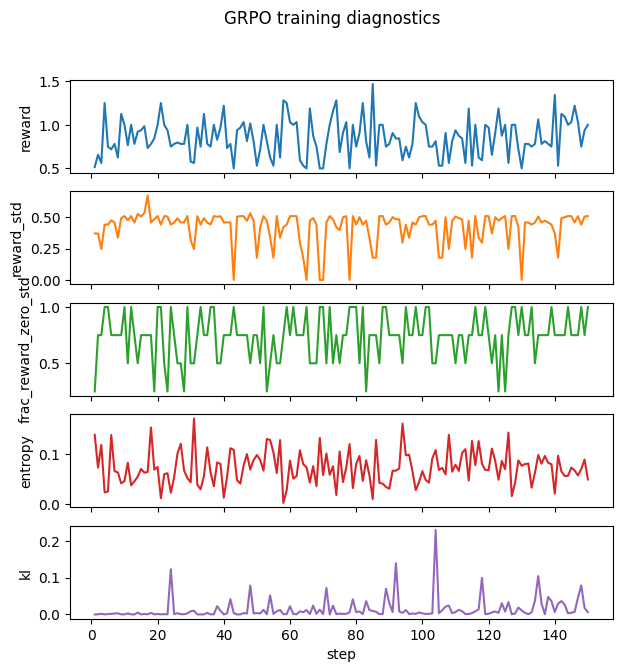

In [12]:
import pandas as pd

history = pd.DataFrame(trainer.state.log_history)
columns = [c for c in ["step", "reward", "reward_std", "frac_reward_zero_std", "entropy", "kl",
                       "rewards/format_reward/mean", "rewards/correctness_reward/mean"]
           if c in history.columns]
display(history[columns].tail(8))

axes = history.plot(x="step", subplots=True, figsize=(7, 7), legend=False,
                    y=[c for c in ["reward", "reward_std", "frac_reward_zero_std", "entropy", "kl"]
                       if c in history.columns],
                    title="GRPO training diagnostics")
for ax in axes:
    ax.set_ylabel(ax.get_legend_handles_labels()[1][0] if ax.get_legend_handles_labels()[1] else "")
axes[-1].set_xlabel("step")

## 6. After

Same held-out problems, same decoding settings — only the adapter has changed. (`generate()` calls
`model.eval()` itself; without that this cell would print garbage and look like a catastrophe.)

In [13]:
tuned_format, tuned_accuracy, tuned_completions = evaluate(trainer.model, eval_rows)

print(f"BEFORE  format {base_format:6.0%}   accuracy {base_accuracy:6.0%}")
print(f"AFTER   format {tuned_format:6.0%}   accuracy {tuned_accuracy:6.0%}")
print("\nsample completions:")
for text in tuned_completions[:5]:
    print(" ", repr(text[:120]))

BEFORE  format    98%   accuracy    41%
AFTER   format   100%   accuracy    41%

sample completions:
  '<answer>34661</answer>'
  '<answer>87785</answer>'
  '<answer>659328</answer>'
  '<answer>267864</answer>'
  '<answer>187557</answer>'


### What to expect from this

**Measured across two full runs of this notebook: format compliance rises to ~100%, and accuracy
does not reliably move** (44% → 44% on one run, 41% → 44% on another — the difference between those
two is eval noise, not learning).

That is the honest result, and it is worth more than a flattering one. What GRPO fixed here was the
part the model could already do and was doing inconsistently: emitting the exact `<answer>` format,
which went to 100%. What it did not do is teach three-digit multiplication in 150 steps — a hard
thing to install in a model that cannot use scratch space — we forbade reasoning tokens with `enable_thinking=False`, so the model
must produce six digits in one shot.

That is the lesson to take away: **RLVR sharpens behaviour the base model can already produce; it
does not add ability the model lacks.** Expect format, style, refusal behaviour and answer-shape to
respond quickly, and raw capability to barely move.

If you want to watch the machinery work on a task where the reward *does* climb, the fastest edit is
to make the format genuinely hard for the base model — require, say, the digits comma-separated as
`<answer>109,052</answer>` — and keep everything else the same. If you want a large, visible jump on this task,
the effective change is not more RL steps — it is allowing a scratchpad (drop `enable_thinking=False`
and raise `max_completion_length`), which gives the policy somewhere to do the carrying.

## 7. Save and reload

Only the adapter is saved — ~175 MB against the base model's 17 GB.

In [14]:
adapter_dir = OUTPUT_DIR / "adapter"
trainer.model.save_pretrained(adapter_dir)
tokenizer.save_pretrained(adapter_dir)

print(adapter_dir)
for path in sorted(adapter_dir.iterdir()):
    print(f"  {path.name:<32} {path.stat().st_size / 1e6:8.1f} MB")

/vol/bitbucket/ma5923/llms/runs/qwen3-8b-grpo-multiply/adapter
  README.md                             0.0 MB
  adapter_config.json                   0.0 MB
  adapter_model.safetensors           174.7 MB
  chat_template.jinja                   0.0 MB
  tokenizer.json                       11.4 MB
  tokenizer_config.json                 0.0 MB


To use it later, load the base model and attach the adapter:

```python
from peft import PeftModel

model = AutoModelForCausalLM.from_pretrained(MODEL_PATH, dtype=torch.bfloat16, device_map={"": 0})
model = PeftModel.from_pretrained(model, adapter_dir)

# Optional: fold the adapter into the weights for faster inference / export to vLLM.
model = model.merge_and_unload()
model.save_pretrained("/vol/bitbucket/ma5923/llms/Qwen3-8B-multiply")
```

## Scaling this up

**Generation is the bottleneck, not the backward pass.** HF `generate()` is the slow path. Install
vLLM and set `use_vllm=True, vllm_mode="colocate"` — typically 5–10× on step time, and the highest-value
change available. Your second L40 is free for exactly this.

**Check `frac_reward_zero_std` before anything else.** Section 2 exists because a run can look
perfectly healthy — loss printed, steps ticking, reward high — while every advantage is zero. Measure
within-group spread on any new task before launching.

**Real datasets.** GSM8K (`openai/gsm8k`) or MATH, parsing the reference answer out of the solution
as the verifier. Nothing else in this notebook changes: swap `make_problems` for `load_dataset`.

**Longer runs.** `save_strategy="steps"` with `save_steps`, and `report_to="wandb"` for durable
curves. Note that `runs/` here is outside the repo; the same overwrite-in-place caution that applies
to `artifacts/` applies to it.

**Memory, if you go bigger.** In order of what to reach for: shorten `max_completion_length`, lower
`num_generations`, keep `gradient_checkpointing` on, then 4-bit base weights via `bitsandbytes`
(QLoRA). Full-parameter RL on 8B needs ~8 GPUs of this class, or DeepSpeed ZeRO-3.